# Classificação de Imagens com MobileNetV3 (timm)

Este notebook utiliza o modelo `mobilenetv3_small_100.lamb_in1k` da biblioteca `timm` (PyTorch Image Models) para classificar as imagens contidas na pasta `imagens`.

In [1]:
import os
import torch
import urllib.request
from PIL import Image
import timm

# Nome do modelo a ser utilizado (MobileNetV3 Small otimizado com LAMB no ImageNet)
model_name = 'mobilenetv3_small_100.lamb_in1k'
print(f"Carregando o modelo: {model_name}...")
model = timm.create_model(model_name, pretrained=True)
model.eval() # Coloca o modelo em modo de avaliação

# Obtém as transformações ideais para o modelo (tamanho de recorte, normalização, etc.)
data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)
print("\nTransformações (transforms) aplicadas às imagens:")
print(transforms)

# Baixa os nomes das categorias do ImageNet para decifrar as previsões
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
try:
    req = urllib.request.urlopen(url)
    categories = [s.strip() for s in req.read().decode('utf-8').splitlines()]
    print("\nModelo e classes carregados com sucesso!")
except Exception as e:
    print(f"Erro ao baixar as classes do ImageNet: {e}")
    categories = [f"Classe {i}" for i in range(1000)]

Carregando o modelo: mobilenetv3_small_100.lamb_in1k...


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

c:\Users\ednar\OneDrive\Imagens\recog_system\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ednar\.cache\huggingface\hub\models--timm--mobilenetv3_small_100.lamb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



Transformações (transforms) aplicadas às imagens:
Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)

Modelo e classes carregados com sucesso!


Encontradas 4 imagens na pasta 'imagens'. Iniciando a classificação...

📍 Analisando: bird.jpg


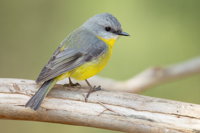


🔥 Top 5 Previsões:
   1. bulbul: 14.61%
   2. chickadee: 11.93%
   3. junco: 9.97%
   4. indigo bunting: 4.83%
   5. jay: 4.60%


📍 Analisando: cats_dog.png


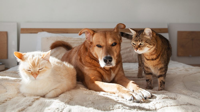


🔥 Top 5 Previsões:
   1. Rhodesian ridgeback: 12.38%
   2. basenji: 12.06%
   3. dingo: 9.30%
   4. redbone: 6.86%
   5. kelpie: 3.58%


📍 Analisando: kitchen.png


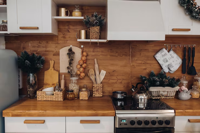


🔥 Top 5 Previsões:
   1. plate rack: 11.20%
   2. dining table: 10.31%
   3. altar: 8.53%
   4. microwave: 5.08%
   5. china cabinet: 4.85%


📍 Analisando: pizza.png


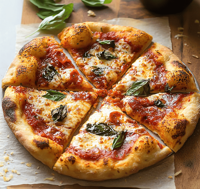


🔥 Top 5 Previsões:
   1. pizza: 96.76%
   2. French loaf: 0.31%
   3. pretzel: 0.20%
   4. hot pot: 0.14%
   5. soup bowl: 0.11%




In [2]:
image_dir = 'imagens'

if not os.path.exists(image_dir):
    print(f"A pasta '{image_dir}' não existe.")
else:
    # Procura todos os arquivos de imagem na pasta
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print("Nenhuma imagem encontrada na pasta.")
    else:
        print(f"Encontradas {len(image_files)} imagens na pasta '{image_dir}'. Iniciando a classificação...\n")
        
        for img_file in image_files:
            img_path = os.path.join(image_dir, img_file)
            try:
                # Carrega a imagem e garante que esteja em formato RGB
                img = Image.open(img_path).convert('RGB')
                
                # Exibe a imagem de forma nativa no notebook em tamanho reduzido
                print("=" * 50)
                print(f"📍 Analisando: {img_file}")
                print("=" * 50)
                # Exibir num tamanho menor para não ocupar toda a tela
                display(img.copy().resize((200, int(200 * img.height / img.width))))
                
                # Prepara o tensor (aplica transforms e adiciona dimensão de lote)
                input_tensor = transforms(img).unsqueeze(0)
                
                # Inferência
                with torch.no_grad():
                    output = model(input_tensor)
                    
                # Calcula probabilidades aplicando softmax e pega os 5 maiores valores
                probabilities = torch.nn.functional.softmax(output[0], dim=0)
                top5_prob, top5_catid = torch.topk(probabilities, 5)
                
                print("\n🔥 Top 5 Previsões:")
                for i in range(top5_prob.size(0)):
                    category = categories[top5_catid[i]]
                    prob = top5_prob[i].item() * 100
                    print(f"   {i+1}. {category}: {prob:.2f}%")
                print("\n")
                    
            except Exception as e:
                print(f"Erro processando a imagem {img_file}: {e}\n")
